In [11]:
!pip install datasets


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from datasets import load_dataset
dataset = load_dataset("amazon_polarity")

In [13]:
import pandas as pd
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

In [14]:
df_train = pd.DataFrame(dataset["train"])
df_train.sample(4)

,label,title,content
3127000,1,Nice!,"Good recipes, lots of variety and even suggest..."
1133520,0,$687? What?,I don't care how wonderful this movie is. $687...
2740993,0,Far From Perfect,"Sorry to say, these Sealy Best Fit sheets were..."
3380871,0,Disappointed,"Before I bought the book, I read the negative ..."


In [15]:
!pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='label'>

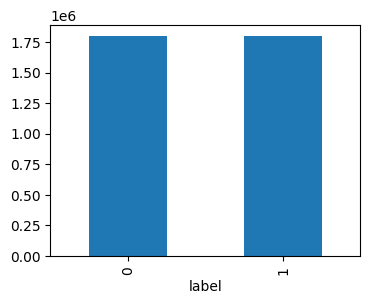

In [16]:
plt.figure(figsize=(4,3))
df_train.groupby("label").size().plot(kind="bar")


<Axes: xlabel='label'>

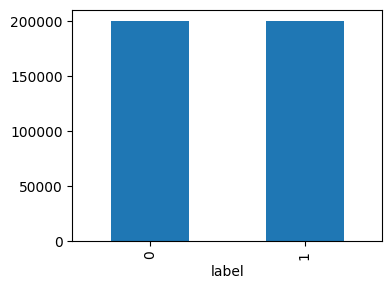

In [17]:
df_test = pd.DataFrame(dataset["test"])
plt.figure(figsize=(4,3))
df_test.groupby("label").size().plot(kind="bar")

In [18]:
!pip install collection
from collections import Counter


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from collections import Counter
print(
    Counter(
        " ".join(
            df_train["title"]
                .str.lower()
                .values
        ).split()
    ).most_common(5)
)

[('the', 488026), ('a', 423730), ('not', 298203), ('of', 257353), ('great', 251930)]


In [20]:
#5. Using `sklearn`'s `CountVectorizer` build the observation matrix corresponding the train & the test sets
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(df_train["content"])
X_test = vectorizer.transform(df_test["content"])
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_train.shape}")


In [22]:
print(len(vectorizer.vocabulary_))

355610


Train accuracy: 0.8550225
Test accuracy: 0.848715


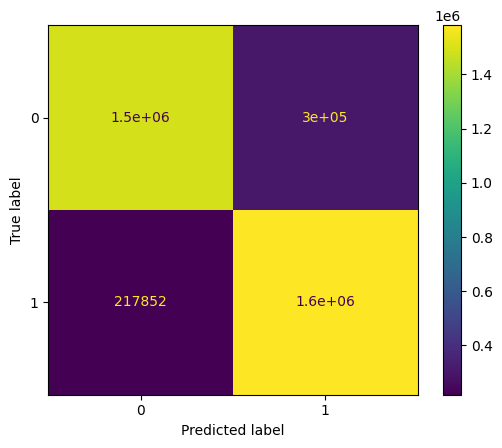

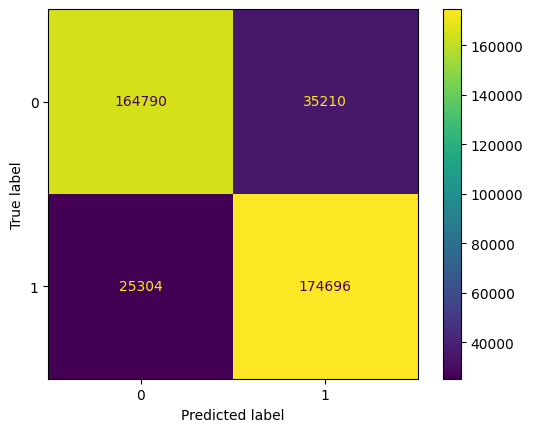

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train = vectorizer.fit_transform(df_train["title"])
X_test = vectorizer.transform(df_test["title"])

Y_train = df_train["label"]
Y_test = df_test["label"]

model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(Y_train, train_pred)
test_acc = accuracy_score(Y_test, test_pred)

print(f"Train accuracy: {train_acc}")
print(f"Test accuracy: {test_acc}")

train_conf_plot = ConfusionMatrixDisplay.from_estimator(model, X_train, Y_train)
test_conf_plot = ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

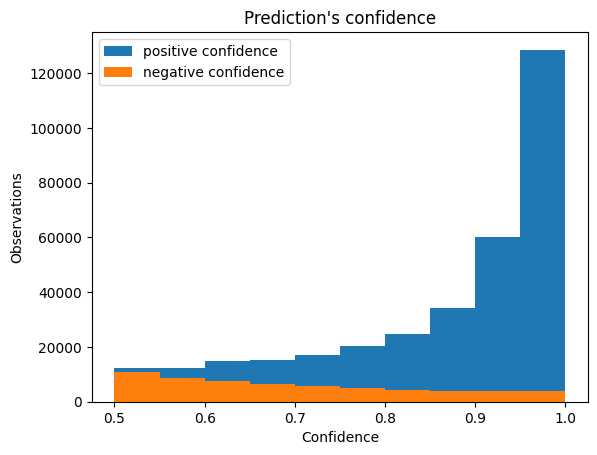

In [24]:
import numpy as np
proba_test = model.predict_proba(X_test)
total_conf = np.max(proba_test, axis=1)

pos_conf = total_conf[Y_test == test_pred]
neg_conf = total_conf[Y_test != test_pred]

plt.hist(pos_conf, label="positive confidence")
plt.hist(neg_conf, label="negative confidence")

plt.xlabel("Confidence")
plt.ylabel("Observations")
plt.title("Prediction's confidence")
plt.legend()

plt.show

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.svm import l1_min_c

C_min = l1_min_c(X_train, Y_train, loss="log") * 10


model = LogisticRegression(solver="liblinear", 
                           penalty="l1", 
                           C=C_min, 
                           max_iter=1_000)

model.fit(X_train, Y_train)

coefs = model.coef_[0]
words = np.array(vectorizer.get_feature_names_out())

top100_idx = np.argsort(np.abs(coefs))[::-1][:100]
top100_words = words[top100_idx]
top100_coefs = coefs[top100_idx]

for word, weight in zip(top100_words, top100_coefs):
    print(word, weight)


not -1.7867768474062515
great 1.6077645158391736
best 1.2484105240628514
excellent 1.2113418418027566
poor -0.8820546173547541
good 0.8169315007444201
love 0.7759692760979884
don -0.7536358391481106
waste -0.6181510329847543
bad -0.5574075865729993
disappointing -0.41334720794747243
disappointed -0.36825449367396246
worst -0.364108197747975
too -0.30431637255004623
no -0.30331452757208144
awesome 0.23619590500942836
terrible -0.16504437350831622
money -0.11634152737348923
the 0.09717040764570162
for 0.08685958990060126
book 0.06924351763672491
this -0.0685229823525146
and 0.04045973310393188
fun 0.03363689008658713
horrible -0.0035236838485135603
003 0.0
002 0.0
0019 0.0
00150 0.0
001 0.0
000th 0.0
00079 0.0
0006 0.0
00027 0.0
0002 0.0
00001 0.0
0000000 0.0
00000 0.0
000 0.0
único 0.0
zzzzzzzzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzzzzzzzzzzzzzz 0.0
zzzzzzzz